# LINEAR REGRESSION USING SCIKIT-LEARN

## Data Preprocessing

In [1]:
import pandas as pd

#Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

#Import Linear Regression Model
from sklearn.linear_model import LinearRegression

#Import StandardScaler to scale/normalize data (helps improve model performance)
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

df = pd.read_csv("area_price_dataset.csv")

print("\n Original Data:")
print(df)


 Original Data:
   Area  Price
0   600     35
1   750     42
2   850     48
3   900     50
4  1000     58
5  1100     65
6  1250     72
7  1400     80
8  1600     92
9  1800    105


## Check for null values

In [ ]:
print("\n Checking null values:")

#isnull() for missing values
#sum() counts the total missing values in each column

print(df.isnull().sum())


 Checking null values:
Area     0
Price    0
dtype: int64


## Split X and y. Splitting X and Y means separating the input(Area) from what we want to predict (Price).

In [ ]:
#Split data into input(X) and output(y)
#X = independent variable (Area used to predict)
X = df[["Area"]]

#y = dependent variable (Price to predict)
y = df["Price"]
print("Splitting X and y used to predict Price...")

Splitting X and y used to predict Price...


## Scaling: Scaling makes all features (columns) equal in range, so the model learns better.
    This code scales the Area values into a small, equal range so the model can learn better.

In [ ]:
#Create Scaler Object
scaler =StandardScaler()

#Scale the input data (Area values)
#fit_transform() = learn pattern (fit) + applier scaling (transform)
X_scaled = scaler.fit_transform(X)

#Scaling = converts large values into similar range so model works better

### T-Test/Z-Test/F-Test tests statistical significance.
### Split means dividing the data into two parts. One for training the model and one for testing it.
### Train-Test-Split tests model performance
### Used for Model Accuracy Checking

## Split data into training and testing sets

In [7]:
#Split data into training and testing sets
# 80% data = training, 20% data = testing

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state = 42) #0.2 = 20% | 42 is the industry standard (just a commonly used number)

#Train Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)

print(" \n Model Trained Successfully! \n")

 
 Model Trained Successfully! 



## Predict for Test Data

In [13]:
# Predict values using test data
#predict() = model gives predicted Price based on Area
y_pred = model.predict(X_test)

print("Actual vs Predicted:")

#Compare real values with predicted values.
#zip() = pairs actual and predicted values together
for actual, pred in zip(y_test, y_pred):
    print(f"Actual: {actual}, Predicted: {pred:.2f}")

Actual vs Predicted:
Actual: 92, Predicted: 92.75
Actual: 42, Predicted: 42.84


## PLOT REGERESSION LINE

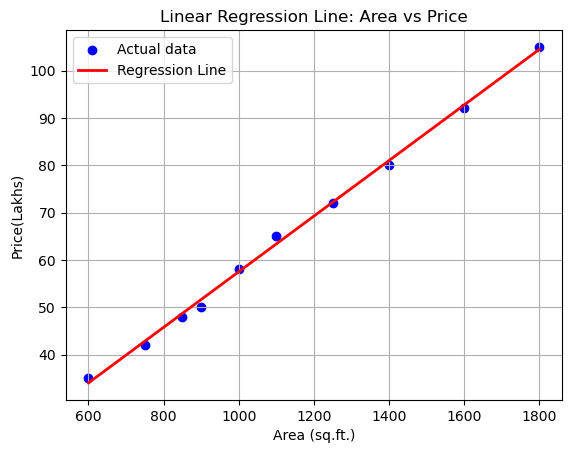

In [9]:
import numpy as np

#Scatter actual data
plt.scatter(df["Area"], df["Price"], color = "blue", label = "Actual data")

#Create smooth area values
area_range = np.linspace(df["Area"].min(), df["Area"].max(), 100)

#Scale them (imp)
area_scaled = scaler.transform(pd.DataFrame({"Area": area_range}))

#Predict prices for smooth line
price_line = model.predict(area_scaled)

#Plot the straight regression line
plt.plot(area_range, price_line, color ="red", linewidth = 2, label ="Regression Line")

plt.xlabel("Area (sq.ft.)")
plt.ylabel("Price(Lakhs)")
plt.title("Linear Regression Line: Area vs Price")
plt.legend()
plt.grid(True)
plt.show()

### Model Predicted 92.75 and Real value was 92

### Prediction is very close (good model)

In [14]:
input_area = float(input("Enter Area (sq.ft.):"))

#Fix: give column name during scaling
scaled_area = scaler.transform(pd.DataFrame({"Area": [input_area]}))

predicted_price = model.predict(scaled_area)

print(f"Predicted Price for Area {input_area} sq.ft. = Rs. {predicted_price[0]: .2f} lakhs")

Enter Area (sq.ft.): 900


Predicted Price for Area 900.0 sq.ft. = Rs.  51.65 lakhs
